# 🏠 House Price Prediction
**Author:** Sharda Vatsal Bhat  
**Dataset:** Kaggle - House Prices: Advanced Regression Techniques  
**Goal:** Predict house sale prices using regression models and compare their performance.

---
### Project Overview
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Model Training & Comparison
- Evaluation & Insights

## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [ ]:
# Load the dataset
# Download from: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
df = pd.read_csv('train.csv')

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Basic dataset information
print('Dataset Info:')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nTarget variable (SalePrice) statistics:')
print(df['SalePrice'].describe())

## Step 3: Exploratory Data Analysis (EDA)

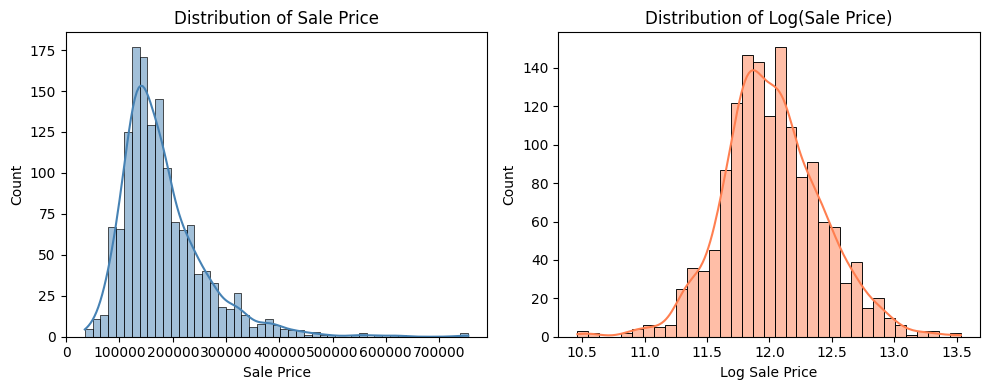

Skewness of SalePrice: 1.88
Skewness of Log(SalePrice): 0.12


In [ ]:
# Distribution of Target Variable (SalePrice)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='coral')
plt.title('Distribution of Log(Sale Price)')
plt.xlabel('Log Sale Price')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print('Skewness of SalePrice:', round(df['SalePrice'].skew(), 2))
print('Skewness of Log(SalePrice):', round(np.log1p(df['SalePrice']).skew(), 2))

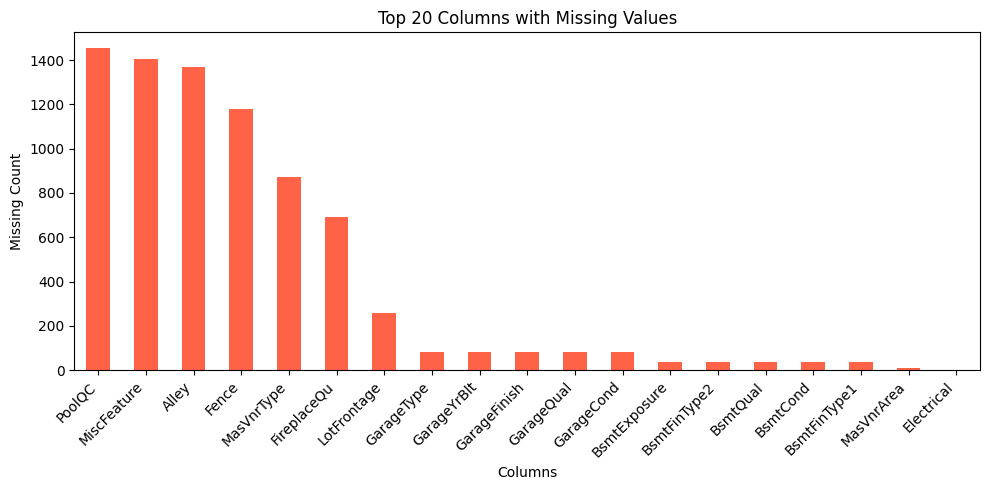

Total columns with missing values: 19


In [ ]:
# Check Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing.head(20).plot(kind='bar', color='tomato')
plt.title('Top 20 Columns with Missing Values')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total columns with missing values: {len(missing)}')

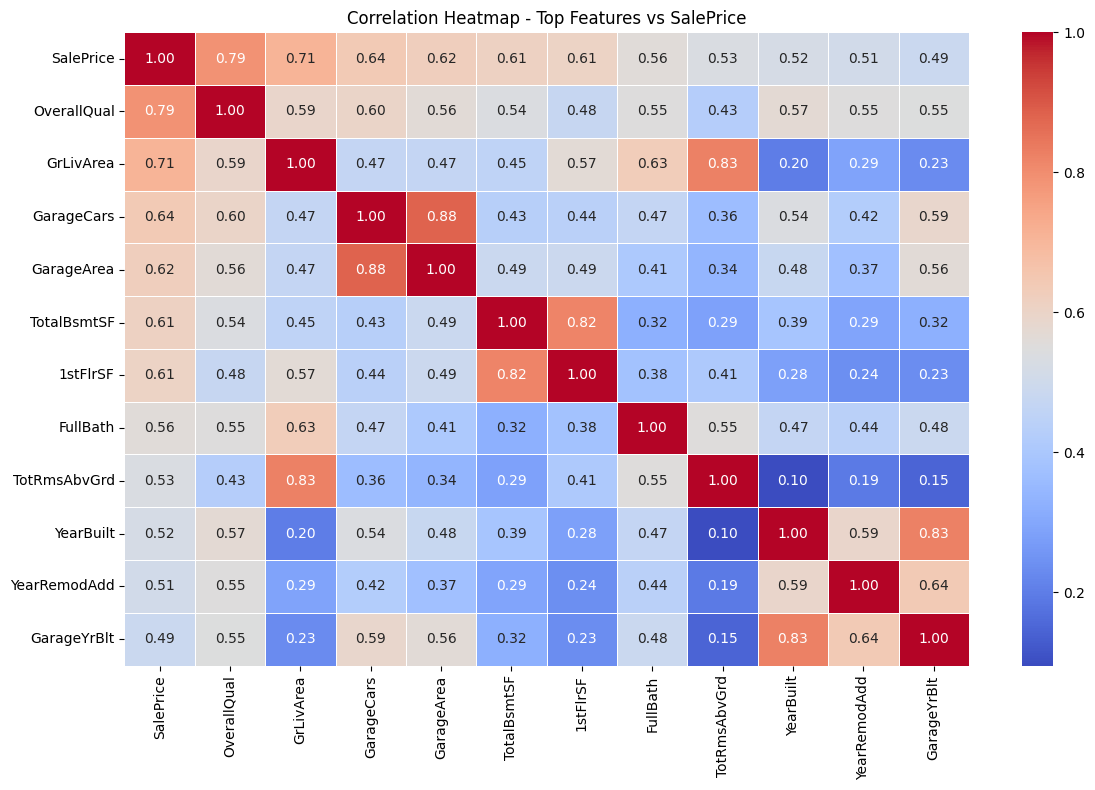

In [ ]:
# Correlation Heatmap (Top Features)
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

# Get top 12 features most correlated with SalePrice
top_features = correlation['SalePrice'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df[top_features].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.tight_layout()
plt.show()

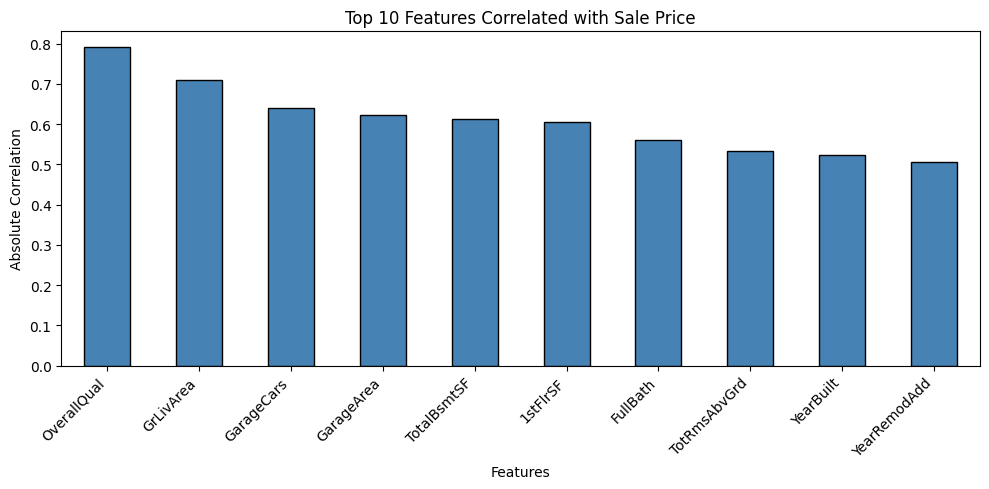

Top 10 Features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [ ]:
# Top 10 Features Correlated with SalePrice
top_corr = correlation['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_corr.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Features Correlated with Sale Price')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 Features:')
print(top_corr)

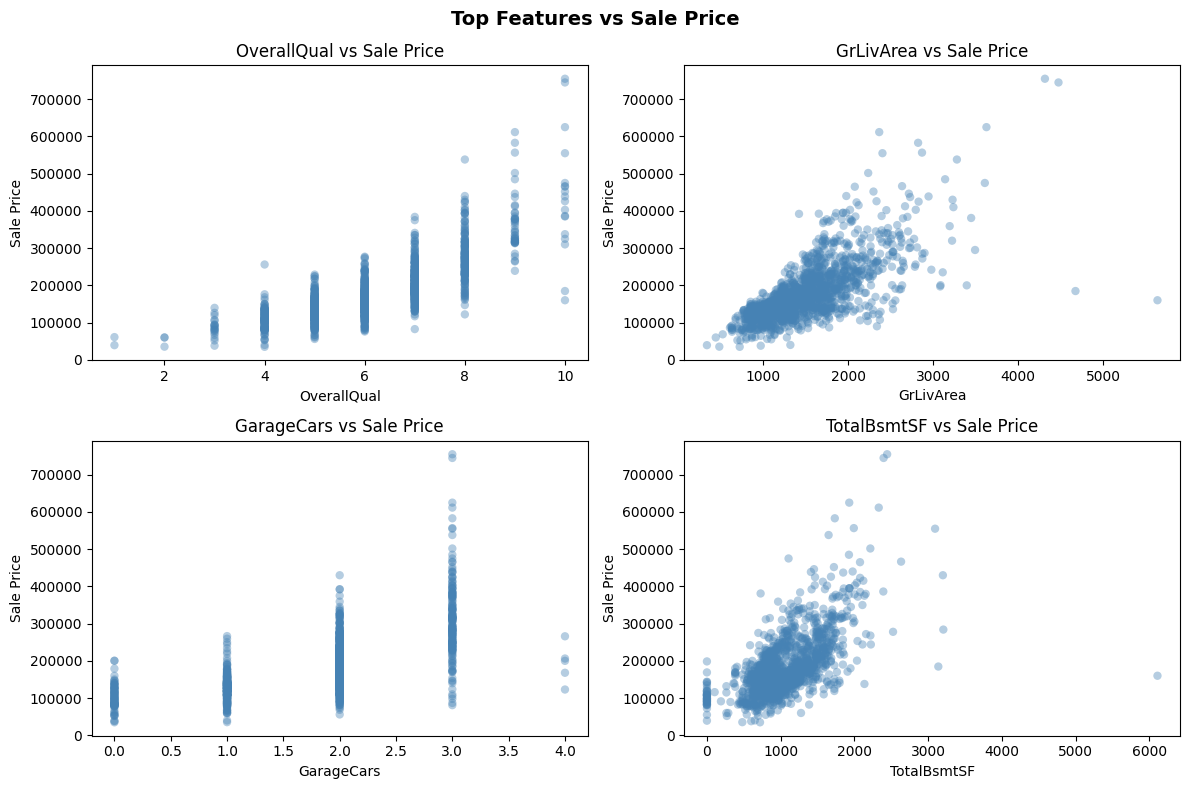

In [ ]:
# Scatter Plots: Top Features vs SalePrice
top_numeric_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top_numeric_features):
    axes[i].scatter(df[feature], df['SalePrice'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price')
    axes[i].set_title(f'{feature} vs Sale Price')

plt.suptitle('Top Features vs Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [ ]:
# Select the most relevant features for the model
selected_features = [
    'OverallQual',    # Overall material and finish quality
    'GrLivArea',      # Above grade living area (sq ft)
    'GarageCars',     # Size of garage in car capacity
    'GarageArea',     # Size of garage in sq ft
    'TotalBsmtSF',    # Total square feet of basement area
    '1stFlrSF',       # First floor square feet
    'FullBath',       # Full bathrooms above grade
    'TotRmsAbvGrd',   # Total rooms above grade
    'YearBuilt',      # Original construction year
    'YearRemodAdd',   # Remodel date
    'Fireplaces',     # Number of fireplaces
    'MasVnrArea',     # Masonry veneer area in sq ft
    'LotArea'         # Lot size in sq ft
]

target = 'SalePrice'

print('Selected features:', len(selected_features))
print(selected_features)

Selected features: 13
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'MasVnrArea', 'LotArea']


In [ ]:
# Handle Missing Values
data = df[selected_features + [target]].copy()

print('Missing values before:')
print(data.isnull().sum())

# Fill missing values with median
for col in selected_features:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)

print('\nMissing values after:')
print(data.isnull().sum())
print('\nDataset shape:', data.shape)

Missing values before:
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
YearRemodAdd    0
Fireplaces      0
MasVnrArea      8
LotArea         0
SalePrice       0
dtype: int64

Missing values after:
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
YearRemodAdd    0
Fireplaces      0
MasVnrArea      0
LotArea         0
SalePrice       0
dtype: int64

Dataset shape: (1460, 14)


In [ ]:
# Train-Test Split
X = data[selected_features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (1168, 13)
Testing set size: (292, 13)


## Step 5: Train Models & Compare

In [ ]:
# Train 3 Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'RMSE': round(rmse, 2), 'R2 Score': round(r2, 4)}
    print(f'{name}:')
    print(f'  RMSE     : {rmse:,.2f}')
    print(f'  R2 Score : {r2:.4f}')
    print()

Linear Regression:
  RMSE     : 38,291.01
  R2 Score : 0.8088

Decision Tree:
  RMSE     : 38,388.37
  R2 Score : 0.8079

Random Forest:
  RMSE     : 28,932.14
  R2 Score : 0.8909



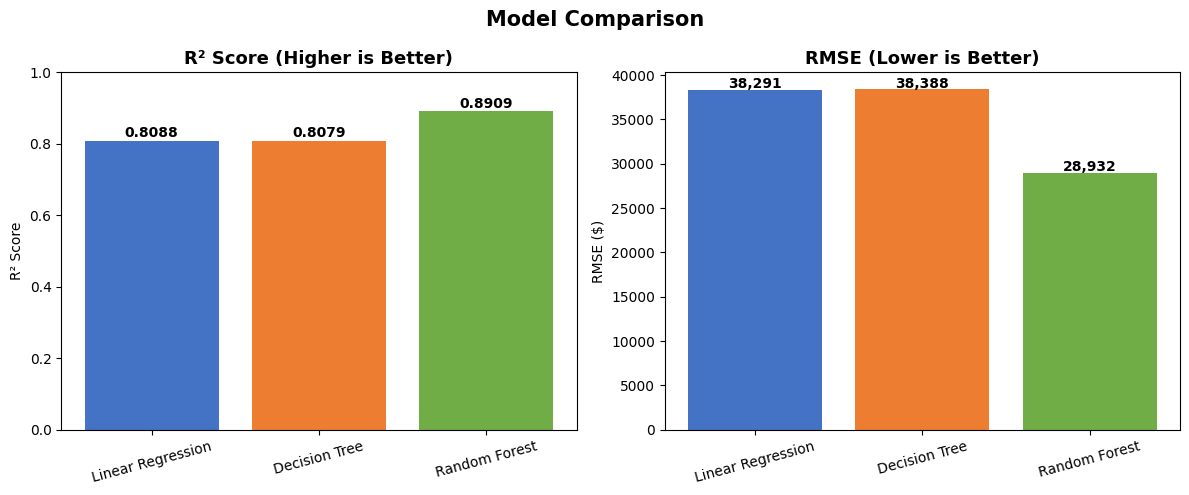


Model Comparison Table:
                       RMSE  R2 Score
Linear Regression  38291.01    0.8088
Decision Tree      38388.37    0.8079
Random Forest      28932.14    0.8909


In [ ]:
# Model Comparison Chart
results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R2 Score
axes[0].bar(results_df.index, results_df['R2 Score'], color=['#4472C4', '#ED7D31', '#70AD47'])
axes[0].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['R2 Score']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

# RMSE
axes[1].bar(results_df.index, results_df['RMSE'], color=['#4472C4', '#ED7D31', '#70AD47'])
axes[1].set_title('RMSE (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 200, f'{v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nModel Comparison Table:')
print(results_df)

## Step 6: Best Model - Feature Importance

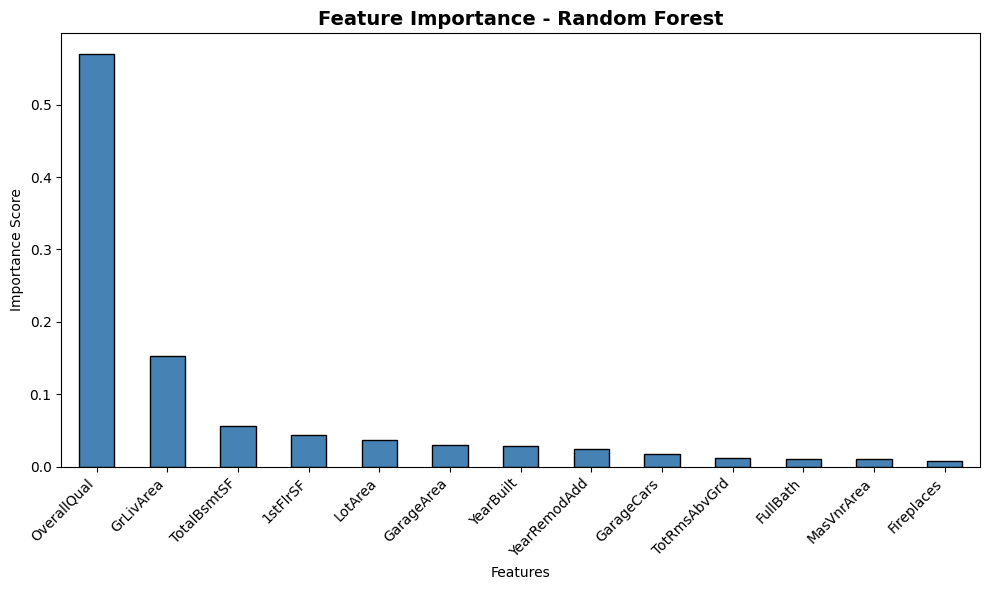


Top 5 Most Important Features:
OverallQual    0.569902
GrLivArea      0.152513
TotalBsmtSF    0.056637
1stFlrSF       0.043172
LotArea        0.036760
dtype: float64


In [ ]:
# Feature Importance from Random Forest (Best Model)
rf_model = models['Random Forest']

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(feature_importance.head())

## Step 7: Actual vs Predicted Prices

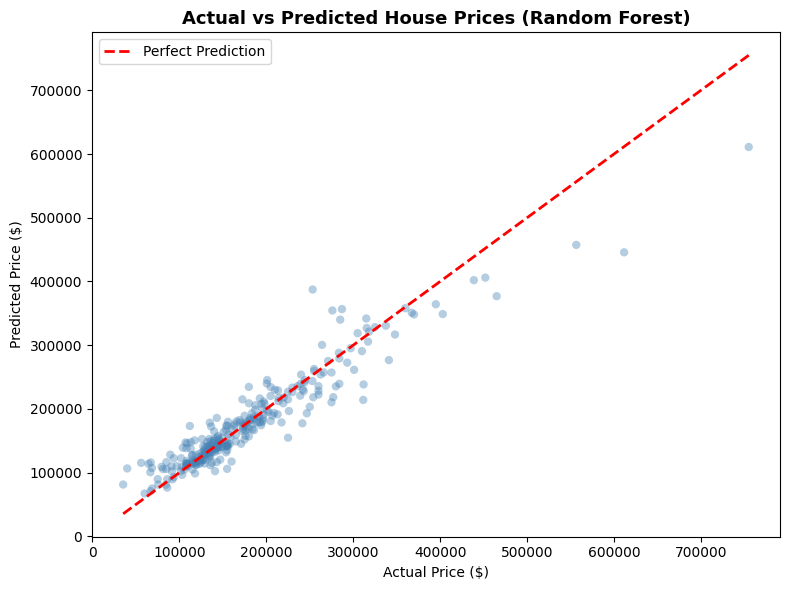

In [ ]:
# Actual vs Predicted - Random Forest
y_pred_rf = models['Random Forest'].predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices (Random Forest)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Residual Plot
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_rf, residuals, alpha=0.4, color='coral', edgecolors='none')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Residual Statistics:')
print(f'  Mean Residual  : {residuals.mean():,.2f}')
print(f'  Std  Residual  : {residuals.std():,.2f}')

## Step 8: Final Summary & Conclusions

In [ ]:
# Print Final Summary
print('=' * 55)
print('         HOUSE PRICE PREDICTION - FINAL SUMMARY')
print('=' * 55)
print(f'\nDataset    : {df.shape[0]} houses, {df.shape[1]} features')
print(f'Features   : {len(selected_features)} selected for modeling')
print(f'Train/Test : 80% / 20% split')
print()
print('Model Performance:')
print('-' * 45)
print(f'{"Model":<25} {"R2 Score":>10} {"RMSE":>10}')
print('-' * 45)
for model_name, metrics in results.items():
    print(f'{model_name:<25} {metrics["R2 Score"]:>10} {metrics["RMSE"]:>10,.0f}')
print('-' * 45)
print()
print('Best Model   : Random Forest')
print()
print('Key Findings:')
print('  - OverallQual is the strongest predictor')
print('  - GrLivArea (living area sq ft) is #2 predictor')
print('  - Random Forest outperforms Linear Regression')
print('    and Decision Tree on both R2 Score and RMSE')
print('  - Tree-based models handle non-linear')
print('    relationships better in this dataset')
print()
print('=' * 55)

         HOUSE PRICE PREDICTION - FINAL SUMMARY

Dataset    : 1460 houses, 81 features
Features   : 13 selected for modeling
Train/Test : 80% / 20% split

Model Performance:
---------------------------------------------
Model                       R2 Score       RMSE
---------------------------------------------
Linear Regression             0.8088     38,291
Decision Tree                 0.8079     38,388
Random Forest                 0.8909     28,932
---------------------------------------------

Best Model   : Random Forest

Key Findings:
  - OverallQual is the strongest predictor
  - GrLivArea (living area sq ft) is #2 predictor
  - Random Forest outperforms Linear Regression
    and Decision Tree on both R2 Score and RMSE
  - Tree-based models handle non-linear
    relationships better in this dataset

